This notebook:

Uses a ResNet18 pretrained on ImageNet, fine-tuned on emotion classification.

**The key insight:**

ResNet18 has already learned to extract general visual
features from millions of images. By treating spectrograms as images, we
might benefit from features that transfer across speakers — testing whether
a larger, more experienced model can close the val-test generalization gap
seen in 1-channel CNN and 3-channel CNN.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

In [2]:
TRAIN_CSV = "train_split.csv"
VAL_CSV   = "val_split.csv"
TEST_CSV  = "test_split.csv"

# ResNet18 expects 3-channel input — perfect fit for our delta spectrograms
MEL_PATH_COL = "mel3_path"
LABEL_COL    = "label"

NUM_CLASSES  = 7
BATCH_SIZE   = 32
LEARNING_RATE = 1e-4     # Lower than Models 1/2 — pretrained weights need gentle updates
WEIGHT_DECAY  = 1e-4
NUM_EPOCHS   = 30        # Fewer epochs — transfer learning converges faster
PATIENCE     = 7
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Two fine-tuning modes:
#   "frozen"      = freeze backbone, train only classifier head (fastest, ~minutes on CPU)
#   "last_blocks" = unfreeze last 2 residual blocks + head (slower, more flexible)
FINE_TUNE_MODE = "last_blocks"

# Load Dataset

To make it fit for the ResNet we load the dataset the same way we have for the CNN models but resizing it to 224×224

In [4]:
class MelSpectrogramResNetDataset(Dataset):
    """
    Loads 3-channel spectrograms and resizes to 224×224 (ResNet's input size).
    Normalizes using ImageNet mean/std so pretrained weights work properly.
    """

    # ImageNet stats — ResNet18 was trained expecting this normalization
    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    IMAGENET_STD  = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

    def __init__(self, source, mel_col=MEL_PATH_COL, label_col=LABEL_COL,
                 target_size=224, augment=False):
        if isinstance(source, str):
            self.df = pd.read_csv(source)
        else:
            self.df = source.copy()
        self.mel_col = mel_col
        self.label_col = label_col
        self.target_size = target_size
        self.augment = augment
        self.df = self.df.dropna(subset=[mel_col, label_col]).reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mel = np.load(row[self.mel_col])  # Shape: (3, 128, T)

        # Normalize each channel to [0, 1] range before applying ImageNet stats
        for c in range(mel.shape[0]):
            ch_min, ch_max = mel[c].min(), mel[c].max()
            if ch_max > ch_min:
                mel[c] = (mel[c] - ch_min) / (ch_max - ch_min)

        # Apply SpecAugment before resizing
        if self.augment:
            t_width = np.random.randint(5, 25)
            t_start = np.random.randint(0, max(1, mel.shape[2] - t_width))
            mel[:, :, t_start:t_start + t_width] = 0
            f_width = np.random.randint(5, 20)
            f_start = np.random.randint(0, max(1, mel.shape[1] - f_width))
            mel[:, f_start:f_start + f_width, :] = 0

        # Resize to 224×224 using simple bilinear interpolation via torch
        mel_tensor = torch.FloatTensor(mel).unsqueeze(0)  # (1, 3, 128, T)
        mel_tensor = torch.nn.functional.interpolate(
            mel_tensor, size=(self.target_size, self.target_size),
            mode="bilinear", align_corners=False,
        ).squeeze(0)  # (3, 224, 224)

        # Apply ImageNet normalization
        mel_np = mel_tensor.numpy()
        mel_np = (mel_np - self.IMAGENET_MEAN) / self.IMAGENET_STD

        return torch.FloatTensor(mel_np), torch.LongTensor([int(row[self.label_col])]).squeeze()

# Pretrained ResNet18 Model with new classifier head

In [5]:
def build_resnet18(num_classes=NUM_CLASSES, fine_tune_mode=FINE_TUNE_MODE):
    """
    Load ResNet18 pretrained on ImageNet, replace the classifier head,
    and selectively freeze layers.
    """
    # Load pretrained model
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if fine_tune_mode == "frozen":
        # Freeze all backbone weights — train only the new classifier head
        for param in model.parameters():
            param.requires_grad = False

    elif fine_tune_mode == "last_blocks":
        # Freeze early layers, unfreeze the last 2 residual blocks (layer3, layer4)
        for name, param in model.named_parameters():
            if "layer3" in name or "layer4" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

    elif fine_tune_mode == "full":
        # Train everything (slowest, riskiest)
        for param in model.parameters():
            param.requires_grad = True

    # Replace the final FC layer with our emotion classifier
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, num_classes),
    )

    return model

# Training Utility Functions

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for mel, labels in loader:
        mel, labels = mel.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(mel)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * mel.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / len(loader.dataset), f1_score(all_labels, all_preds, average="weighted")

In [7]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for mel, labels in loader:
            mel, labels = mel.to(device), labels.to(device)
            outputs = model(mel)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * mel.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return (running_loss / len(loader.dataset),
            f1_score(all_labels, all_preds, average="weighted"),
            all_preds, all_labels)

In [8]:
def plot_training_curves(train_losses, val_losses, train_f1s, val_f1s, save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(train_losses) + 1)
    ax1.plot(epochs, train_losses, "b-", label="Train Loss", linewidth=2)
    ax1.plot(epochs, val_losses, "r-", label="Val Loss", linewidth=2)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title(f"Model 3 (ResNet18, {FINE_TUNE_MODE}) — Loss")
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(epochs, train_f1s, "b-", label="Train F1", linewidth=2)
    ax2.plot(epochs, val_f1s, "r-", label="Val F1", linewidth=2)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Weighted F1")
    ax2.set_title(f"Model 3 (ResNet18, {FINE_TUNE_MODE}) — F1")
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [9]:
def plot_confusion_matrix(labels, preds, label_names, save_path=None):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Model 3 (ResNet18) — Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# Running the Pretrained ResNet Model

In [10]:
print(f"Device: {DEVICE}")
print(f"Fine-tune mode: {FINE_TUNE_MODE}")

train_dataset = MelSpectrogramResNetDataset(TRAIN_CSV, augment=True)
val_dataset   = MelSpectrogramResNetDataset(VAL_CSV,   augment=False)
test_dataset  = MelSpectrogramResNetDataset(TEST_CSV,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} clips")
print(f"Val:   {len(val_dataset)} clips")
print(f"Test:  {len(test_dataset)} clips")

sample_mel, _ = train_dataset[0]
print(f"Sample input shape: {sample_mel.shape}  (should be (3, 224, 224))")

Device: cpu
Fine-tune mode: last_blocks
Train: 2982 clips
Val:   630 clips
Test:  328 clips
Sample input shape: torch.Size([3, 224, 224])  (should be (3, 224, 224))


In [11]:
# Class weights
train_labels = train_dataset.df[LABEL_COL].values.astype(int)
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

# Build the model
model = build_resnet18(num_classes=NUM_CLASSES, fine_tune_mode=FINE_TUNE_MODE).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Shann/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 78.0MB/s]



Total parameters:     11,243,079
Trainable parameters: 10,560,007  (93.9%)


In [12]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Only optimize parameters that require gradients
trainable = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

In [13]:
# Training loop
train_losses, val_losses, train_f1s, val_f1s = [], [], [], []
best_val_f1 = 0.0
patience_counter = 0
best_model_path = os.path.join(f"best_cnn_model3_{FINE_TUNE_MODE}.pt")

print("\n" + "=" * 60)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train F1':>8} | {'Val F1':>8}")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_f1, _, _ = validate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_f1s.append(train_f1); val_f1s.append(val_f1)

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>10.4f} | {train_f1:>8.4f} | {val_f1:>8.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val F1: {best_val_f1:.4f}")
            break

print(f"\nTraining complete. Best validation F1: {best_val_f1:.4f}")


Epoch | Train Loss |   Val Loss | Train F1 |   Val F1
    1 |     1.7301 |     0.7895 |   0.3214 |   0.8090
    2 |     1.0091 |     0.4336 |   0.6493 |   0.8455
    3 |     0.7130 |     0.3718 |   0.7482 |   0.8644
    4 |     0.5937 |     0.3392 |   0.7957 |   0.8749
    5 |     0.5284 |     0.3328 |   0.8163 |   0.8807
    6 |     0.4682 |     0.2732 |   0.8444 |   0.8998
    7 |     0.3899 |     0.2994 |   0.8735 |   0.9015
    8 |     0.3408 |     0.3170 |   0.8857 |   0.8930
    9 |     0.2937 |     0.2618 |   0.9057 |   0.9077
   10 |     0.2408 |     0.3370 |   0.9215 |   0.8940
   11 |     0.2441 |     0.2859 |   0.9231 |   0.9093
   12 |     0.1794 |     0.3011 |   0.9433 |   0.9109
   13 |     0.1579 |     0.3419 |   0.9503 |   0.9081
   14 |     0.1164 |     0.2674 |   0.9665 |   0.9191
   15 |     0.0879 |     0.3015 |   0.9732 |   0.9224
   16 |     0.0853 |     0.2955 |   0.9745 |   0.9237
   17 |     0.0861 |     0.2642 |   0.9725 |   0.9269
   18 |     0.0704 |     0.

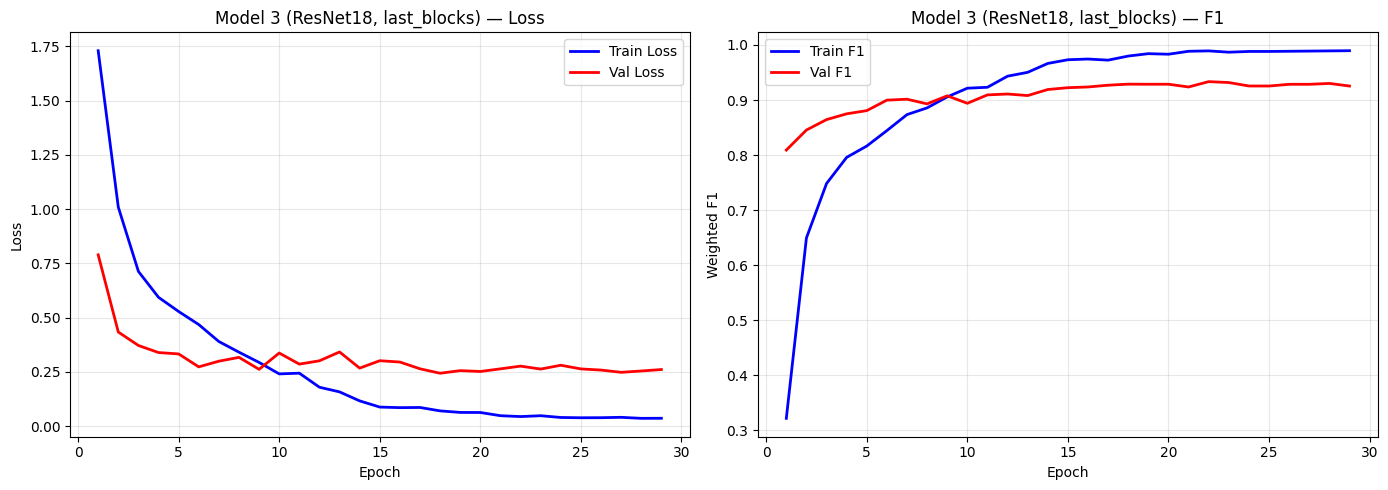

In [14]:
plot_training_curves(train_losses, val_losses, train_f1s, val_f1s,
                         save_path=os.path.join(f"model3_{FINE_TUNE_MODE}_curves.png"))


In [15]:
# Final test evaluation
print("\n" + "=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)
model.load_state_dict(torch.load(best_model_path, weights_only=True))
test_loss, test_f1, test_preds, test_labels = validate(model, test_loader, criterion, DEVICE)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Weighted F1: {test_f1:.4f}")


FINAL EVALUATION ON TEST SET

Test Loss: 2.7155
Test Weighted F1: 0.4882


In [16]:
# Load label names
label_names = [str(i) for i in range(NUM_CLASSES)]
if os.path.exists("label_map.json"):
    with open("label_map.json", "r") as f:
        label_data = json.load(f)
    if "int_to_label" in label_data:
        int_to_label = label_data["int_to_label"]
    else:
        int_to_label = {str(v): k for k, v in label_data.items()}
    label_names = [int_to_label[str(i)] for i in range(NUM_CLASSES)]

print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

       angry       0.47      0.66      0.55        47
     disgust       0.40      0.36      0.38        47
     fearful       0.68      0.40      0.51        47
       happy       0.58      0.38      0.46        47
     neutral       0.46      0.80      0.58        46
         sad       0.27      0.32      0.29        47
   surprised       0.96      0.49      0.65        47

    accuracy                           0.49       328
   macro avg       0.54      0.49      0.49       328
weighted avg       0.54      0.49      0.49       328



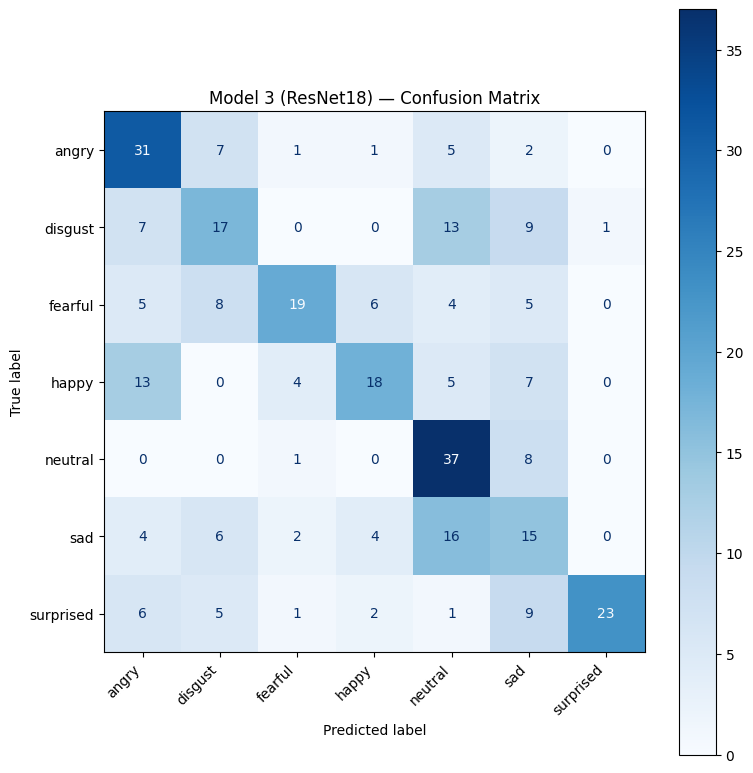

In [17]:
plot_confusion_matrix(test_labels, test_preds, label_names,
                          save_path=os.path.join(f"model3_{FINE_TUNE_MODE}_confusion.png"))

In [18]:
# Save results
results = {
    "model": f"CNN_Model3_ResNet18_{FINE_TUNE_MODE}",
    "input": "mel_spectrogram_3channel_resized_to_224",
    "best_val_f1": round(best_val_f1, 4),
    "test_f1": round(test_f1, 4),
    "test_loss": round(test_loss, 4),
    "total_params": total_params,
    "trainable_params": trainable_params,
    "epochs_trained": len(train_losses),
}
with open(os.path.join(f"model3_{FINE_TUNE_MODE}_results.json"), "w") as f:
    json.dump(results, f, indent=2)
print(f"\nResults: {json.dumps(results, indent=2)}")


Results: {
  "model": "CNN_Model3_ResNet18_last_blocks",
  "input": "mel_spectrogram_3channel_resized_to_224",
  "best_val_f1": 0.9334,
  "test_f1": 0.4882,
  "test_loss": 2.7155,
  "total_params": 11243079,
  "trainable_params": 10560007,
  "epochs_trained": 29
}


In [19]:
# Three-way comparison
print("\n" + "=" * 70)
print("THREE-WAY COMPARISON")
print("=" * 70)
print(f"{'Metric':<20} {'Model 1':>12} {'Model 2':>12} {'Model 3':>12}")
print("-" * 70)

m1, m2 = None, None
if os.path.exists(os.path.join("1channel_cnn_results.json")):
    with open(os.path.join("1channel_cnn_results.json")) as f: m1 = json.load(f)
if os.path.exists(os.path.join("model2_results.json")):
    with open(os.path.join("model2_results.json")) as f: m2 = json.load(f)

if m1 and m2:
    print(f"{'Best Val F1':<20} {m1['best_val_f1']:>12.4f} {m2['best_val_f1']:>12.4f} {best_val_f1:>12.4f}")
    print(f"{'Test F1':<20} {m1['test_f1']:>12.4f} {m2['test_f1']:>12.4f} {test_f1:>12.4f}")
    gap1 = m1["best_val_f1"] - m1["test_f1"]
    gap2 = m2["best_val_f1"] - m2["test_f1"]
    gap3 = best_val_f1 - test_f1
    print(f"{'Val-Test Gap':<20} {gap1:>12.4f} {gap2:>12.4f} {gap3:>12.4f}")
print(f"{'Parameters':<20} {m1['total_params']:>12,} {m2['total_params']:>12,} {total_params:>12,}")


THREE-WAY COMPARISON
Metric                    Model 1      Model 2      Model 3
----------------------------------------------------------------------
Best Val F1                0.7137       0.6236       0.9334
Test F1                    0.2169       0.2240       0.4882
Val-Test Gap               0.4968       0.3996       0.4452
Parameters                422,599      423,175   11,243,079


# Model Results and Discussion

Comparing the pretrained ResNet to the 1-channel CNN and 3-channel CNN from before, we see a noticeable improvement in performance. We see that the test F1 score has improved from ~0.22 to 0.49, which is nearly double. 

One of the major reasons the test F1 score improved so dramatically was because the model was not collapsing to a 'neutral' option anymore. When we compare the per-class F1 scores, every emotion improves including disgust and happy. In the previous models they struggled to classify an emotion as happy or disgust, so it took the safe option and went with neutral, which drastically hurt the F1 score. Now disgust and happy sit at a 0.38 and 0.46 F1 score respectively. This is the most important indicator that the model is learning real patterns rather than defaulting to a safe guess.

The other reason the pretrained ResNet performed so well was because ResNet18 was already trained on millions of photos, which allowed it to learn low-level visual features like edges, textures, and gradients. This meant that when we finetuned the model to our spectrogram dataset, it only had to learn the specific bits about emotion. This is unlike our custom CNNs from before, where we're trying to train it to learn everything about speech and emotion patterns from scratch using only ~3000 training clips. This matters a lot for speaker generalizability because the ResNet model's features ignore speaker identity and focus only on the underlying structure of the spectrogram, while the custom CNNs may accidentally pick up patterns that correlate with specific training speakers. 

There is also a difference in the setup of the model's depth and residual connections. Our custom CNNs only had 4 layers while the pretrained ResNet18 had 18 stations. More stations means more refined analysis is possible: the model can learn hierarchical patterns like low-level frequency patterns, mid-level rhythmic patterns, and high-level emotional expressions. The ResNet18 also comes with an interesting and useful feature called **residual connections** that allow it to send information directly to later stations and not just the subsequent station, meaning that important early findings in our features can be preserved no matter how deep the network gets, which simply isn't possible in our custom CNNs since it would reach a complexity ceiling much sooner.

Despite these improvements, the validation-test gap remains significant (val F1 of 0.93 vs test F1 of 0.49). This tells us that even with pretrained features, the model still benefits significantly from having seen each speaker during training. This is a fundamental limitation of cross-speaker speech emotion recognition and likely needs different and much more advanced techniques to fully address.